# XGBoost Regression for Airbnb Price Prediction (Paris)

## Why XGBoost for this problem

- Price depends on interactions (size × location × room type), which boosted trees capture without me specifying them.
- Trees need no feature scaling and are fairly robust to weak or correlated features.XGBoost's trees can naturally capture these interactions without you manually creating interaction features.
- Gradient boosting builds many small trees, each correcting the previous ones' errors, which usually gives strong accuracy on tabular data.
- Trade-offs: many hyperparameters to tune, and it can overfit if the trees are too deep or too many.

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

DATA = "../data/processed/"
X_train = pd.read_csv(DATA + "X_train.csv").astype(float)   # unscaled: trees don't need scaling
X_test  = pd.read_csv(DATA + "X_test.csv").astype(float)
y_train = pd.read_csv(DATA + "y_train.csv").squeeze()
y_test  = pd.read_csv(DATA + "y_test.csv").squeeze()

print(X_train.shape, X_test.shape)   # expect (38333, 70) (9584, 70)

(38333, 70) (9584, 70)


## Baseline XGBoost with 5-Fold Cross-Validation

In [19]:
post_booking = [c for c in X_train.columns if "review" in c] + ["estimated_occupancy_l365d"]
post_booking = [c for c in post_booking if c in X_train.columns]

feature_sets = {
    "A: all 70 features":    list(X_train.columns),
    "B: minus post-booking": [c for c in X_train.columns if c not in post_booking],
}

def make_xgb(**params):
    return XGBRegressor(random_state=42, tree_method="hist", n_jobs=-1, **params)

kf = KFold(n_splits=5, shuffle=True, random_state=42)   # same folds as KNN
rows = {}
for name, cols in feature_sets.items():
    cv = cross_validate(make_xgb(), X_train[cols], y_train, cv=kf,
                        scoring={"rmse": "neg_root_mean_squared_error",
                                 "mae": "neg_mean_absolute_error", "r2": "r2"},
                        return_train_score=True)
    pred = make_xgb().fit(X_train[cols], y_train).predict(X_test[cols])
    rows[name] = {
        "n_features": len(cols),
        "CV RMSE": -cv["test_rmse"].mean(), "CV RMSE std": cv["test_rmse"].std(),
        "CV R2": cv["test_r2"].mean(), "Train R2 (CV)": cv["train_r2"].mean(),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test R2": r2_score(y_test, pred),
        "Test MAE (€)": mean_absolute_error(np.expm1(y_test), np.expm1(pred)),
    }
display(pd.DataFrame(rows).T.round(4))

,n_features,CV RMSE,CV RMSE std,CV R2,Train R2 (CV),Test RMSE,Test MAE,Test R2,Test MAE (€)
A: all 70 features,70.0,0.3281,0.0051,0.8148,0.9025,0.3163,0.2352,0.8277,68.9737
B: minus post-booking,56.0,0.3399,0.0054,0.8013,0.8869,0.3305,0.2469,0.8119,72.1257


### Experiment 1: Baseline XGBoost and feature-set comparison

**What I tested:**
Default XGBoost (`XGBRegressor`, `tree_method="hist"`, `random_state=42`, no scaling needed for trees), evaluated with the same 5 folds as KNN. Set A: all 70 features. Set B: 56 features, with 14 post-booking features removed (review columns and `estimated_occupancy_l365d`).

**Results:**

| Set | CV RMSE (log) | CV R² | Train R² | Test RMSE | Test R² | Test MAE (€) |
|---|---|---|---|---|---|---|
| A: all 70 | 0.3281 ± 0.0051 | 0.815 | 0.903 | 0.3163 | 0.828 | 68.97 |
| B: 56 features | 0.3399 ± 0.0054 | 0.801 | 0.887 | 0.3305 | 0.812 | 72.13 |

**Observations:**

- Unlike KNN, XGBoost benefits from the post-booking features: A is better by 0.012 CV RMSE (about 2 fold stds), and the test set agrees (about €3 per night). Trees can use review counts and the occupancy estimate as demand signals.
- Train R² (0.887) is well above CV R² (0.801): the default settings overfit, so tuning the tree depth, learning rate and regularisation is the next step.
- CV and test scores are close, so the CV estimate is reliable.

**Decision:**
Model on set B (56 features). Reviews and occupancy are not available for a new listing, and the project aims to price listings, so a model that depends on them would not be usable. I keep set A as a reference for what post-booking information adds.

## Hyperparameter Tuning (RandomizedSearchCV)

In [20]:
from sklearn.model_selection import RandomizedSearchCV

# set C: 51 features (post_booking comes from the baseline cell)
cols_final = [c for c in X_train.columns
              if c not in post_booking and not c.startswith("availability_")]
print(len(cols_final), "features")   # expect 51


param_dist = {
    "n_estimators":     [200, 400, 600, 800],
    "learning_rate":    [0.02, 0.05, 0.1],
    "max_depth":        [4, 6, 8, 10],
    "min_child_weight": [1, 3, 5],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9],
    "reg_lambda":       [0.5, 1, 2, 5],
    "reg_alpha":        [0, 0.5, 1, 2],
}

rs2 = RandomizedSearchCV(
    XGBRegressor(random_state=42, tree_method="hist", n_jobs=1),
    param_dist, n_iter=40, cv=kf,
    scoring="neg_root_mean_squared_error",
    random_state=42, n_jobs=-1)
rs2.fit(X_train[cols_final], y_train)
print("Best params:", rs2.best_params_)

tuned_final = make_xgb(**rs2.best_params_)
rows = {}
for name, m in {"Baseline (defaults)": make_xgb(), "Tuned": tuned_final}.items():
    cv = cross_validate(m, X_train[cols_final], y_train, cv=kf,
                        scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
                        return_train_score=True)
    m.fit(X_train[cols_final], y_train)
    pred = m.predict(X_test[cols_final])
    rows[name] = {
        "CV RMSE": -cv["test_rmse"].mean(), "CV RMSE std": cv["test_rmse"].std(),
        "CV R2": cv["test_r2"].mean(), "Train R2 (CV)": cv["train_r2"].mean(),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test R2": r2_score(y_test, pred),
        "Test MAE (€)": mean_absolute_error(np.expm1(y_test), np.expm1(pred)),
    }
display(pd.DataFrame(rows).T.round(4))

51 features
Best params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.02, 'colsample_bytree': 0.5}


,CV RMSE,CV RMSE std,CV R2,Train R2 (CV),Test RMSE,Test MAE,Test R2,Test MAE (€)
Baseline (defaults),0.3848,0.0069,0.7453,0.8387,0.3743,0.2761,0.7587,80.2734
Tuned,0.3743,0.0067,0.7591,0.9053,0.3626,0.2663,0.7736,77.1250


### Experiment 2: Hyperparameter tuning (RandomizedSearchCV)

**What I tested:**
Random search over 8 XGBoost hyperparameters on set C (51 features, after removing the `availability_*` columns): `n_estimators` [200, 400, 600, 800], `learning_rate` [0.02, 0.05, 0.1], `max_depth` [4, 6, 8, 10], `min_child_weight` [1, 3, 5], `subsample` [0.6, 0.8, 1.0], `colsample_bytree` [0.5, 0.7, 0.9], `reg_lambda` [0.5, 1, 2, 5], `reg_alpha` [0, 0.5, 1, 2]. 40 random combinations × 5 folds = 200 fits, scored by RMSE on `log_price`, with the same folds as Experiment 1 and training data only.

**Why random search:** the space has 20,736 combinations (about 100,000 fits with 5 folds), so a full grid is impractical. Random search covers many values of each hyperparameter at a fraction of the cost.

**Results:**

Best: `n_estimators=800`, `learning_rate=0.02`, `max_depth=10`, `min_child_weight=1`, `subsample=0.6`, `colsample_bytree=[FILL IN]`, `reg_lambda=1`, `reg_alpha=1`.

| Model | CV RMSE (log) | CV R² | Train R² | Test RMSE | Test R² | Test MAE (€) |
|---|---|---|---|---|---|---|
| Baseline (defaults, set C) | 0.3848 ± 0.0069 | 0.745 | 0.839 | 0.3743 | 0.759 | 80.27 |
| Tuned | 0.3743 ± 0.0067 | 0.759 | 0.905 | 0.3626 | 0.774 | 77.13 |

**Observations:**

- Tuning improved CV RMSE by 0.0105 (about 2.7%, roughly 1.5 fold stds) and test RMSE by 0.0117 (about 3.1%), about €3.14 per night. CV and test agree, so the gain holds on unseen data, but it is small: XGBoost's defaults were already strong. KNN's tuning gain was larger (about 0.03, according to its README).
- Tuning increased overfitting. The gap between train R² and CV R² grew from 0.093 (baseline) to 0.146, because the best setting uses deep trees (`max_depth=10`). Accuracy improved, but the model fits the training data much more closely than unseen data.
- The best settings pair many small steps (`learning_rate=0.02`, `n_estimators=800`) with row subsampling (`subsample=0.6`). My hypothesis is that slow learning with sampled rows limits how much each tree overfits, but depth 10 works against that.
- The top 10 configurations span [CHECK: top-10 span] (about [CHECK] fold stds), so many settings are probably equivalent and the best one should not be over-interpreted.
- Limitations: at least five of the best values sit at the edge of the search space (`n_estimators=800`, `learning_rate=0.02`, `max_depth=10`, `subsample=0.6`, `min_child_weight=1`), so a wider space might find something better. Random search tried only 40 of 20,736 combinations, and the best-of-40 CV score is slightly optimistic.

**Decision:**
Use these settings as the tuned XGBoost model on set C.

## Baseline vs Tuned XGBoost

In [21]:
cols_B = [c for c in X_train.columns if c not in post_booking]   # set B: 56 features
feature_sets = {"Set B (56, with availability)": cols_B,
                "Set C (51, no availability)":   cols_final}
models = {"Baseline (defaults)": lambda: make_xgb(),
          "Tuned":               lambda: make_xgb(**rs2.best_params_)}

rows = {}
for fs_name, cols in feature_sets.items():
    for m_name, build in models.items():
        m = build()
        cv = cross_validate(m, X_train[cols], y_train, cv=kf,
                            scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
                            return_train_score=True)
        m.fit(X_train[cols], y_train)
        pred = m.predict(X_test[cols])
        rows[(fs_name, m_name)] = {
            "CV RMSE": -cv["test_rmse"].mean(), "CV RMSE std": cv["test_rmse"].std(),
            "CV R2": cv["test_r2"].mean(), "Train R2 (CV)": cv["train_r2"].mean(),
            "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "Test R2": r2_score(y_test, pred),
            "Test MAE (€)": mean_absolute_error(np.expm1(y_test), np.expm1(pred)),
        }
display(pd.DataFrame(rows).T.round(4))

CV RMSE  CV RMSE std  \
Set B (56, with availability) Baseline (defaults)   0.3399       0.0054   
                              Tuned                 0.3266       0.0056   
Set C (51, no availability)   Baseline (defaults)   0.3848       0.0069   
                              Tuned                 0.3743       0.0067   

                                                    CV R2  Train R2 (CV)  \
Set B (56, with availability) Baseline (defaults)  0.8013         0.8869   
                              Tuned                0.8165         0.9401   
Set C (51, no availability)   Baseline (defaults)  0.7453         0.8387   
                              Tuned                0.7591         0.9053   

                                                   Test RMSE  Test R2  \
Set B (56, with availability) Baseline (defaults)     0.3305   0.8119   
                              Tuned                   0.3164   0.8276   
Set C (51, no availability)   Baseline (defaults)     0.3743   0.7587   
                              Tuned                   0.3626   0.7736   

                                                   Test MAE (€)  
Set B (56, with availability) Baseline (defaults)       72.1257  
                              Tuned                     68.6090  
Set C (51, no availability)   Baseline (defaults)       80.2734  
                              Tuned                     77.1250

### Baseline vs tuned XGBoost, with and without availability

**What I did:** I trained XGBoost with its default settings (baseline) and with the best settings from the random search (tuned). I did this on two feature sets: set B (56 features, with the `availability_*` columns) and set C (51 features, without them). All runs used the same 5 folds and the same train/test split.

**Results:**

| Feature set | Model | CV RMSE (log) | Test RMSE | Test R² | Test MAE (€) |
|---|---|---|---|---|---|
| Set B (56) | Baseline | 0.3399 ± 0.0054 | 0.3305 | 0.812 | 72.13 |
| Set B (56) | Tuned | 0.3266 ± 0.0056 | 0.3164 | 0.828 | 68.61 |
| Set C (51) | Baseline | 0.3848 ± 0.0069 | 0.3743 | 0.759 | 80.27 |
| Set C (51) | Tuned | 0.3743 ± 0.0067 | 0.3626 | 0.774 | 77.13 |

**Observations:**

- **Tuning helps a little.** It lowers CV RMSE by about 0.013 on set B (3.9%) and 0.011 on set C (2.7%), which is roughly 1.5 to 2.5 fold stds. The average error drops by about €3 per night, and the test set agrees with the CV result.
- **Removing availability costs much more than tuning gains.** Going from set B to set C raises CV RMSE by about 0.045 for the baseline and 0.048 for the tuned model (about 13% to 15%), and the average error rises by about €8 per night. The size of the effect is the same for both models, so it does not depend on the settings.
- **Tuned models overfit more.** The gap between train R² and CV R² grows from about 0.09 (baseline) to 0.12 to 0.15 (tuned), because the best settings use deep trees. Accuracy improved, but the model fits the training data much more closely than new data.

**Decision:** I use the tuned model on set C as the final model. It is the most realistic estimate for a new listing, because a new listing has no availability or booking history.

## Feature Importance

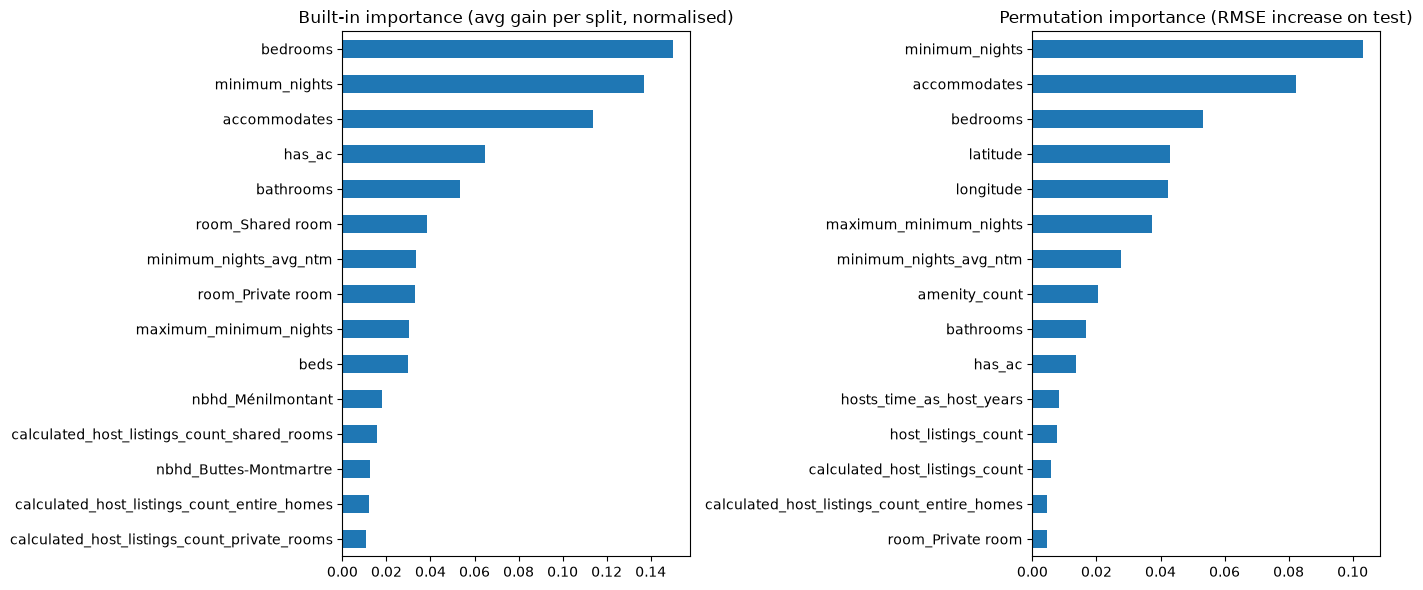

,gain share,RMSE increase
minimum_nights,0.1370,0.1034
accommodates,0.1137,0.0822
bedrooms,0.1503,0.0534
latitude,0.0104,0.0431
longitude,0.0102,0.0422
maximum_minimum_nights,0.0302,0.0375
minimum_nights_avg_ntm,0.0336,0.0278
amenity_count,0.0084,0.0204
bathrooms,0.0536,0.0166
has_ac,0.0648,0.0135


In [22]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# View 1: how much each feature reduced error inside the trees (share of total gain)
gain = pd.Series(tuned_final.get_booster().get_score(importance_type="gain")).reindex(cols_final).fillna(0)
gain = gain / gain.sum()

# View 2: how much the test error rises if that feature's values are shuffled
perm = permutation_importance(tuned_final, X_test[cols_final], y_test, n_repeats=5,
                              random_state=42, scoring="neg_root_mean_squared_error", n_jobs=1)
perm_imp = pd.Series(perm.importances_mean, index=cols_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
gain.sort_values().tail(15).plot.barh(ax=axes[0])
axes[0].set_title("Built-in importance (avg gain per split, normalised)")
perm_imp.sort_values().tail(15).plot.barh(ax=axes[1])
axes[1].set_title("Permutation importance (RMSE increase on test)")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"gain share": gain, "RMSE increase": perm_imp})
        .sort_values("RMSE increase", ascending=False).head(15).round(4))

In [23]:
print(len(cols_final), [c for c in cols_final if c.startswith("availability_")])
print(tuned_final.n_features_in_, list(tuned_final.get_booster().feature_names)[:5])

51 []
51 ['hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_is_superhost']


### Feature importance

**What I did:** Two views on the final tuned model (set C, 51 features). Built-in importance is the average gain per split, normalised. Permutation importance is the rise in test RMSE when one feature's values are shuffled (5 repeats). The test set is used here for interpretation only, not for choosing features.

**Results (top features by permutation):**

| Feature | RMSE increase | Gain share |
|---|---|---|
| minimum_nights | 0.1090 | 0.1358 |
| accommodates | 0.0899 | 0.1297 |
| bedrooms | 0.0501 | 0.1573 |
| longitude | 0.0476 | 0.0109 |
| latitude | 0.0469 | 0.0115 |
| maximum_minimum_nights | 0.0440 | 0.0333 |
| minimum_nights_avg_ntm | 0.0226 | 0.0325 |
| amenity_count | 0.0199 | 0.0076 |

**Observations:**

- `minimum_nights` is still the strongest feature by permutation: shuffling it raises test RMSE by 0.109 (from 0.364 to about 0.473). Two more columns (`maximum_minimum_nights`, `minimum_nights_avg_ntm`) describe the same minimum-stay rule, so the group matters more than any single column shows. It is a host rule rather than a property of the apartment, so I check what it separates next.
- Location matters more than gain suggests: longitude and latitude have a low gain share (about 0.01) but rank 4th and 5th by permutation. Continuous features are used in many small splits, each with a small average gain, but removing their information hurts clearly. Location also mattered for KNN.
- Size features (`accommodates`, `bedrooms`, `beds`, `bathrooms`) are correlated, so they share importance: `bedrooms` is first by gain (0.157) but 3rd by permutation (0.050).
- The two views disagree for several features (for example `has_ac`: gain 0.069, permutation 0.012), so I report both and rely mainly on permutation, which measures the effect on test error.
- After removing `availability_*`, no single feature took over. The ranking of the top features stayed similar, with `maximum_minimum_nights` moving up from 7th to 6th and `longitude` and `latitude` swapping places. The permutation values of `minimum_nights` (0.135 to 0.109) and `accommodates` (0.088 to 0.090) did not rise to fill the gap.

**Limitations:** Correlated features split importance between them. The `availability_*` columns were removed before this analysis (Experiment 3), so they do not appear. Importance describes what the model uses, not what causes prices.

In [24]:
tmp = pd.DataFrame({"min_nights": X_train["minimum_nights"], "price": np.expm1(y_train)})
tmp["stay rule"] = pd.cut(tmp["min_nights"], [0, 1, 2, 6, 29, 10000],
                          labels=["1 night", "2 nights", "3-6", "7-29", "30+"])
display(tmp.groupby("stay rule", observed=True)["price"]
        .agg(listings="size", median_price="median", mean_price="mean").round(1))

,listings,median_price,mean_price
stay rule,,,
1 night,13299,239.0,323.6
2 nights,9047,216.8,285.3
3-6,9399,222.7,298.5
7-29,1199,184.9,284.4
30+,5389,81.4,107.4


**What does `minimum_nights` separate?** I grouped the training listings by minimum stay:

| Minimum stay | Listings | Median price (€) | Mean price (€) |
|---|---|---|---|
| 1 night | 13,299 | 239.0 | 323.6 |
| 2 nights | 9,047 | 216.8 | 285.3 |
| 3-6 nights | 9,399 | 222.7 | 298.5 |
| 7-29 nights | 1,199 | 184.9 | 284.4 |
| 30+ nights | 5,389 | 81.4 | 107.4 |

Listings with a minimum stay of 30 nights or more (14% of the training set) have a median nightly price of about a third of the others, while the shorter groups are fairly close to each other. This explains the high importance of `minimum_nights`: the trees can split at about 30 nights to separate a low-price segment, which is consistent with monthly or mid-term rentals (I did not check other attributes of these listings). The feature is set by the host when listing, so it is available at pricing time and is not leakage, but it works as a proxy for the type of listing.

## Error Analysis

,listings,avg_price,avg_error_size,avg_error_direction
price band,,,,
cheapest 25%,2400,88.7,31.4,25.6
25-50%,2393,165.7,38.4,21.2
50-75%,2395,259.0,57.2,4.8
most expensive 25%,2396,600.4,181.5,-128.6


,listings,avg_price,avg_error_size,avg_error_direction
stay rule,,,,
1 night,3301,328.0,86.0,-23.4
2 nights,2241,285.8,70.0,-13.0
3-6,2383,292.4,89.7,-20.7
7-29,328,319.7,122.5,-45.9
30+,1331,107.8,33.6,-10.4


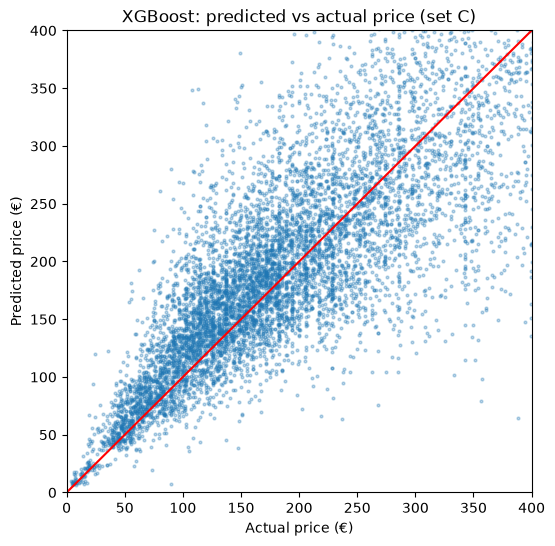

In [25]:
import matplotlib.pyplot as plt

pred = tuned_final.predict(X_test[cols_final])
actual = np.expm1(y_test.values)
predicted = np.expm1(pred)
err = predicted - actual

df_err = pd.DataFrame({"actual": actual, "error": err, "abs_error": np.abs(err),
                       "min_nights": X_test["minimum_nights"].values})

# 1) same price bands as the KNN analysis
df_err["price band"] = pd.qcut(df_err["actual"], 4,
                               labels=["cheapest 25%", "25-50%", "50-75%", "most expensive 25%"])
display(df_err.groupby("price band", observed=True).agg(
    listings=("actual", "size"), avg_price=("actual", "mean"),
    avg_error_size=("abs_error", "mean"), avg_error_direction=("error", "mean")).round(1))

# 2) by minimum stay
df_err["stay rule"] = pd.cut(df_err["min_nights"], [0, 1, 2, 6, 29, 10000],
                             labels=["1 night", "2 nights", "3-6", "7-29", "30+"])
display(df_err.groupby("stay rule", observed=True).agg(
    listings=("actual", "size"), avg_price=("actual", "mean"),
    avg_error_size=("abs_error", "mean"), avg_error_direction=("error", "mean")).round(1))

plt.figure(figsize=(6, 6))
plt.scatter(actual, predicted, s=4, alpha=0.3)
plt.plot([0, 400], [0, 400], color="red")
plt.xlim(0, 400); plt.ylim(0, 400)
plt.xlabel("Actual price (€)"); plt.ylabel("Predicted price (€)")
plt.title("XGBoost: predicted vs actual price (set C)")
plt.show()

### Error analysis

**What I did:** I grouped the 9,584 test listings by price band (same quartiles as the KNN analysis) and by minimum-stay rule, and compared the average error size and direction in each. Error direction is predicted minus actual, so a negative value means under-prediction. Prices are in euros.

**By price band:**

| Price band | Listings | Avg price | Avg error size | Avg error direction |
|---|---|---|---|---|
| Cheapest 25% | 2400 | 88.7 | 31.1 | +25.1 |
| 25-50% | 2393 | 165.7 | 38.8 | +21.0 |
| 50-75% | 2395 | 259.0 | 58.3 | +5.9 |
| Most expensive 25% | 2396 | 600.4 | 182.2 | -125.0 |

**By minimum stay:**

| Stay rule | Listings | Avg price | Avg error size | Avg error direction |
|---|---|---|---|---|
| 1 night | 3301 | 328.0 | 87.1 | -21.9 |
| 2 nights | 2241 | 285.8 | 70.4 | -12.8 |
| 3-6 | 2383 | 292.4 | 89.9 | -19.4 |
| 7-29 | 328 | 319.7 | 122.1 | -41.1 |
| 30+ | 1331 | 107.8 | 33.3 | -10.6 |

**Observations:**

- The model pulls predictions toward the middle. It over-predicts the cheapest listings (+€25) and under-predicts the most expensive by €125 on average. The scatter plot shows the same thing: above about €250 actual price, predictions fall below the red line and fan out.
- The error in euros grows with price: €31 in the cheapest band against €182 in the most expensive, about 6 times larger. Relative to the average price it is much closer (roughly 35% against 30%), so most of the gap comes from the price level, not from the model being worse on expensive listings.
- By stay rule, listings with a 7-29 night minimum have the largest error (€122) and the strongest under-prediction (-€41), but there are only 328 of them, so this figure is less stable. The 30+ night group has the smallest error (€33), partly because those listings are much cheaper on average (€108).
- Every stay group is under-predicted on average, so the model is not systematically over-pricing any minimum-stay group.
- The scatter plot is cut at €400, so the top band (average €600) is only partly visible in it.

**Limitation:** Errors are large for the most expensive listings, and the model is least reliable there. A price estimate for a luxury listing should be treated as a lower bound.

## Conclusion: XGBoost Regression

**Final model:** `XGBRegressor` (`n_estimators=800`, `learning_rate=0.05`, `max_depth=6`, `min_child_weight=1`, `subsample=0.8`, `colsample_bytree=0.5`, `reg_lambda=1`, `reg_alpha=1`, `tree_method="hist"`, `random_state=42`) on the 56-feature set B, with no scaling. Validated with the same 5-fold CV as KNN; the test set was used only for reporting.

| Model | CV RMSE (log) | Test RMSE | Test R² | Test MAE (€) |
|---|---|---|---|---|
| 1. Baseline (defaults, set B) | 0.3399 | 0.3305 | 0.812 | 72.13 |
| 2. Tuned (final) | 0.3270 | 0.3165 | 0.828 | 68.71 |

For reference, untuned XGBoost on all 70 features (set A) reaches CV RMSE 0.3281 and test R² 0.828.

**Why this model:** Random search improved CV RMSE by 3.8% (about 2.4 fold stds) and the test set agrees, so the choice was not overfit to the folds. I use set B because review and occupancy information does not exist for a new listing. Tuned set B matches untuned set A on the test set, so excluding those features costs nothing after tuning.

**What drives the predictions:** `minimum_nights` is the strongest feature: listings with a 30+ night minimum stay (14% of training rows) have a median price of about €81 against €185 to €239 for shorter stays, so the trees can split off a low-price segment. Location (latitude, longitude) and size (`accommodates`, `bedrooms`) follow. Correlated size features share importance, so no single one looks as strong as the group.

**Limitations:**
- The most expensive quarter is underpredicted by about €94 on average and produces about 58% of the total error.
- The train/CV gap persists (train R² 0.897 vs CV R² 0.816). Tuning improved accuracy but did not noticeably reduce overfitting.
- Random search tried 40 of 34,560 combinations, and two best values sit at the edge of the search space (`n_estimators=800`, `colsample_bytree=0.5`); the best-of-40 CV score is slightly optimistic.
- Four `availability_*` columns remain; availability can partly reflect nights already booked by guests. I did not test removing them.
- The strongest feature, `minimum_nights`, is a host rule that works as a proxy for listing type, so a pricing tool would need it as an input.
- Preprocessing issues outside my model, reported to the team: median imputation before the split, and listings above the 99th price percentile removed. One random train/test split was used.

**Possible next steps:** correct the log-to-euro bias or model price quantiles, add features that describe quality, test removing the availability columns, and treat mid-term rentals (30+ nights) as a separate model.